In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import tensorflow as tf
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [ ]:
fruit_data = pd.read_csv('https://raw.githubusercontent.com/vishwa-Ansh/DataLoaders/refs/heads/main/Data_fruit.csv')
fruit_data

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.9080,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.1440,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.3940,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.2100,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.3540,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
893,255403,1925.3650,691.8453,477.1796,0.7241,570.2536,0.9785,261028,0.7269,1.4499,...,2.2423,2.3704,2.7202,-25296416768,-19168882688,-18473392128,49.0869,43.0422,42.4153,SOGAY
894,365924,2664.8230,855.4633,551.5447,0.7644,682.5752,0.9466,386566,0.6695,1.5510,...,3.4109,3.5805,3.9910,-31605219328,-21945366528,-19277905920,46.8086,39.1046,36.5502,SOGAY
895,254330,1926.7360,747.4943,435.6219,0.8126,569.0545,0.9925,256255,0.7240,1.7159,...,2.2759,2.5090,2.6951,-22242772992,-19594921984,-17592152064,44.1325,40.7986,40.9769,SOGAY
896,238955,1906.2679,716.6485,441.8297,0.7873,551.5859,0.9604,248795,0.6954,1.6220,...,2.6769,2.6874,2.7991,-26048595968,-21299822592,-19809978368,51.2267,45.7162,45.6260,SOGAY


In [ ]:
X = fruit_data.drop('Class', axis=1)
y = fruit_data['Class']


label_encoding  = LabelEncoder()
y = label_encoding.fit_transform(y)

X_train, X_test, y_train , y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_test.shape, y_test.shape)
print(X_train.shape, y_train.shape)

scaler_encoding = StandardScaler()
X_train_scale = scaler_encoding.fit_transform(X_train)
X_test_scale = scaler_encoding.transform(X_test)

X_train_tensor = torch.tensor(X_train_scale, dtype = torch.float32)
X_test_tensor =  torch.tensor(X_test_scale, dtype = torch.float32)

y_train_tensor = torch.tensor(y_train,  dtype = torch.long)
y_test_tensor = torch.tensor(y_test,  dtype=torch.long)
print(X_test_tensor)
print(y_train_tensor)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,  y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle= False)

(180, 34) (180,)
(718, 34) (718,)
tensor([[-1.4681, -1.5104, -1.6110,  ...,  1.7157,  1.8864,  1.3899],
        [-0.3808, -0.2304,  0.0503,  ..., -2.0761, -1.8388, -1.7477],
        [-1.3722, -1.3848, -1.4493,  ..., -0.0923, -0.1138, -0.1319],
        ...,
        [-0.4487, -0.2655, -0.1040,  ...,  0.9154,  0.9146,  0.9736],
        [ 0.5883,  0.3596,  0.2474,  ...,  0.1883,  0.3185,  0.2283],
        [-1.3555, -1.2297, -1.1075,  ...,  1.3047,  1.6137,  1.4415]])
tensor([6, 5, 2, 3, 1, 3, 2, 0, 0, 5, 4, 5, 2, 1, 2, 4, 4, 4, 5, 4, 6, 6, 4, 2,
        5, 5, 5, 4, 4, 2, 4, 6, 5, 6, 2, 0, 5, 1, 4, 3, 1, 2, 6, 2, 2, 3, 2, 5,
        2, 4, 0, 2, 6, 4, 2, 1, 4, 6, 5, 5, 5, 5, 3, 4, 3, 4, 3, 6, 5, 2, 4, 1,
        1, 3, 0, 3, 3, 4, 6, 2, 1, 4, 4, 5, 4, 5, 6, 2, 3, 5, 2, 2, 4, 6, 2, 6,
        1, 6, 2, 5, 5, 1, 1, 3, 6, 1, 2, 0, 4, 2, 2, 4, 4, 3, 1, 2, 0, 4, 4, 1,
        5, 3, 5, 1, 2, 2, 5, 3, 1, 4, 4, 2, 0, 4, 1, 3, 0, 2, 4, 6, 0, 2, 3, 3,
        0, 3, 6, 5, 2, 4, 5, 3, 5, 0, 5, 4, 1, 0, 2,

In [ ]:
X_train = np.asarray(X_train_scale, dtype=np.float32)
X_test = np.asarray(X_test_scale, dtype=np.float32)

y_train = np.asarray(y_train, dtype=np.int32)
y_test = np.asarray(y_test, dtype=np.int32)

model = tf.keras.Sequential([
    tf.keras.layers.Input(
        shape=(X_train.shape[1],)
    ),

    tf.keras.layers.Dense(32),
    tf.keras.layers.ReLU(),

    tf.keras.layers.Dense(32),
    tf.keras.layers.ReLU(),

    tf.keras.layers.Dense(7)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
         learning_rate=0.001
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=["accuracy"]
)

model.summary()

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

logits = model.predict(X_test)

probabilities = tf.nn.softmax(
    logits,
    axis=1
)

print("Probabilities:")
print(probabilities.numpy())

predictions = tf.argmax(
    probabilities,
    axis=1
)

print("Predicted classes:")
print(predictions.numpy())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,407 (9.40 KB)

 Trainable params: 2,407 (9.40 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.2561 - loss: 1.9805 - val_accuracy: 0.3403 - val_loss: 1.6588
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5906 - loss: 1.4360 - val_accuracy: 0.7083 - val_loss: 1.2316
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7404 - loss: 1.0787 - val_accuracy: 0.7292 - val_loss: 0.9249
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7509 - loss: 0.8223 - val_accuracy: 0.7500 - val_loss: 0.7191
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7683 - loss: 0.6664 - val_accuracy: 0.7708 - val_loss: 0.5956
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8101 - loss: 0.5676 - val_accuracy: 0.8403 - val_loss: 0.5183
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8328 - loss: 0.4989 - val_accuracy: 0.8889 - val_loss: 0.4580
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8467 - loss: 0.4480 - val_accuracy: 0.8958

In [ ]:
X_train_tensorflow = np.asarray(X_train_scale, dtype=np.float32)
X_test_tensorflow = np.asarray(X_test_scale, dtype=np.float32
                                )

y_train_tensorflow = np.asarray(y_train, dtype=np.int32)
y_test_tensorflow = np.asarray(y_test, dtype=np.int32)


In [13]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(
        shape=(X_train_tensorflow.shape[1],)
    ),
    tf.keras.layers.Dense(32),
    tf.keras.layers.ReLU(),

    tf.keras.layers.Dense(32),
    tf.keras.layers.ReLU(),

    tf.keras.layers.Dense(7, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
         learning_rate=0.001
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=False
    ),
    metrics=["accuracy"]
)

model.summary()

history = model.fit(
    X_train_tensorflow,
    y_train_tensorflow,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

loss, accuracy = model.evaluate(
    X_test_tensorflow,
    y_test_tensorflow
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,407 (9.40 KB)

 Trainable params: 2,407 (9.40 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5000 - loss: 1.4998 - val_accuracy: 0.6389 - val_loss: 1.2503
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6742 - loss: 1.0609 - val_accuracy: 0.7014 - val_loss: 0.9164
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7300 - loss: 0.8149 - val_accuracy: 0.7431 - val_loss: 0.7246
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7735 - loss: 0.6765 - val_accuracy: 0.7639 - val_loss: 0.6143
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7840 - loss: 0.5823 - val_accuracy: 0.7778 - val_loss: 0.5448
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8049 - loss: 0.5168 - val_accuracy: 0.8333 - val_loss: 0.4884
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8223 - loss: 0.4630 - val_accuracy: 0.8333 - val_loss: 0.4571
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8484 - loss: 0.4226 - val_accuracy: 0.8611 - 

In [24]:
loss = history.history['loss']
accuracy = history.history['accuracy'][-1]
print("Loss:", loss)
print("Accuracy:", accuracy)



Loss: [1.4998319149017334, 1.0609315633773804, 0.8148699998855591, 0.6764658093452454, 0.5823460817337036, 0.5167525410652161, 0.46295294165611267, 0.4225781559944153, 0.39253830909729004, 0.3643288314342499, 0.3445335626602173, 0.32176268100738525, 0.30297473073005676, 0.2877543270587921, 0.2701438367366791, 0.2562430799007416, 0.2448699027299881, 0.23381058871746063, 0.2226066291332245, 0.21232186257839203, 0.20464922487735748, 0.1942639946937561, 0.18753105401992798, 0.18203629553318024, 0.1758146435022354, 0.17440129816532135, 0.16508039832115173, 0.15753352642059326, 0.15355725586414337, 0.14886271953582764, 0.14388041198253632, 0.14470571279525757, 0.14060468971729279, 0.13776175677776337, 0.13187600672245026, 0.12704560160636902, 0.12609471380710602, 0.12246046215295792, 0.11871013790369034, 0.11896586418151855, 0.11692382395267487, 0.11033391207456589, 0.11141683161258698, 0.10830342769622803, 0.1039954200387001, 0.10218587517738342, 0.10311400145292282, 0.10006389766931534, 0.

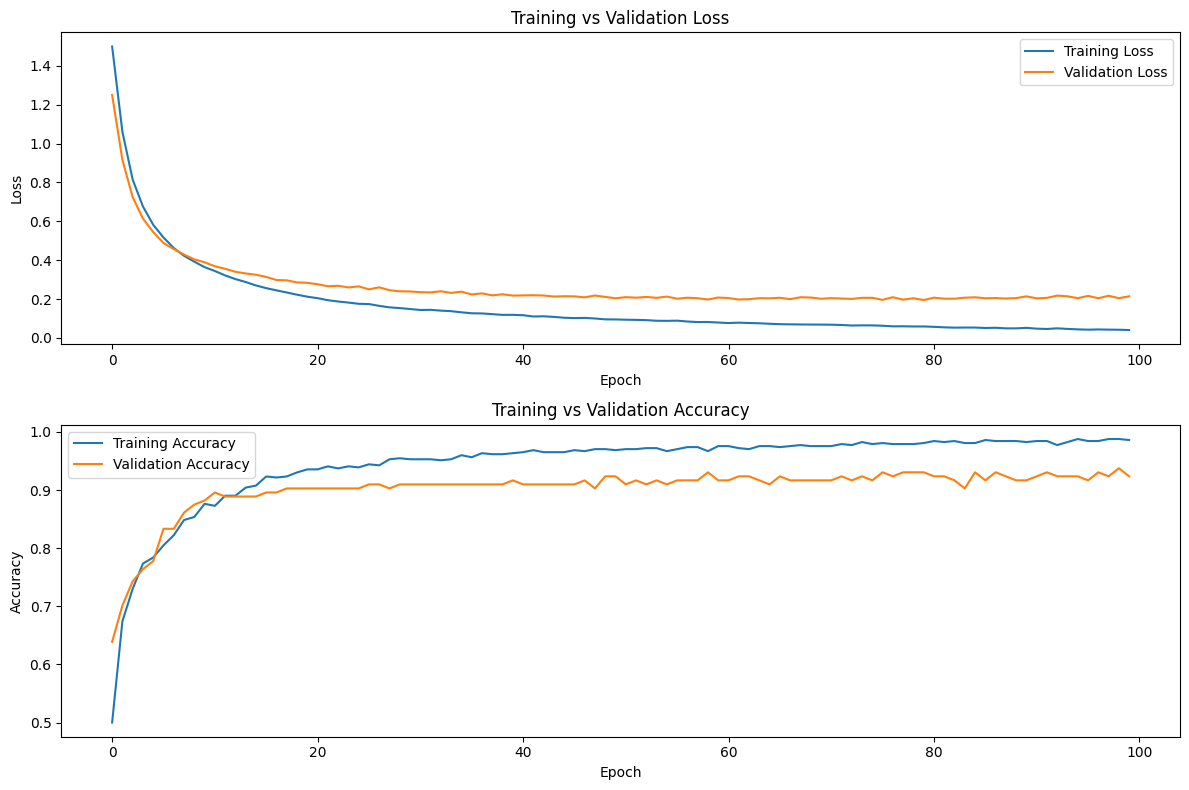

In [31]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()


# 2. Training & Validation Accuracy
plt.subplot(2, 1, 2)

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()


plt.tight_layout()
plt.show()

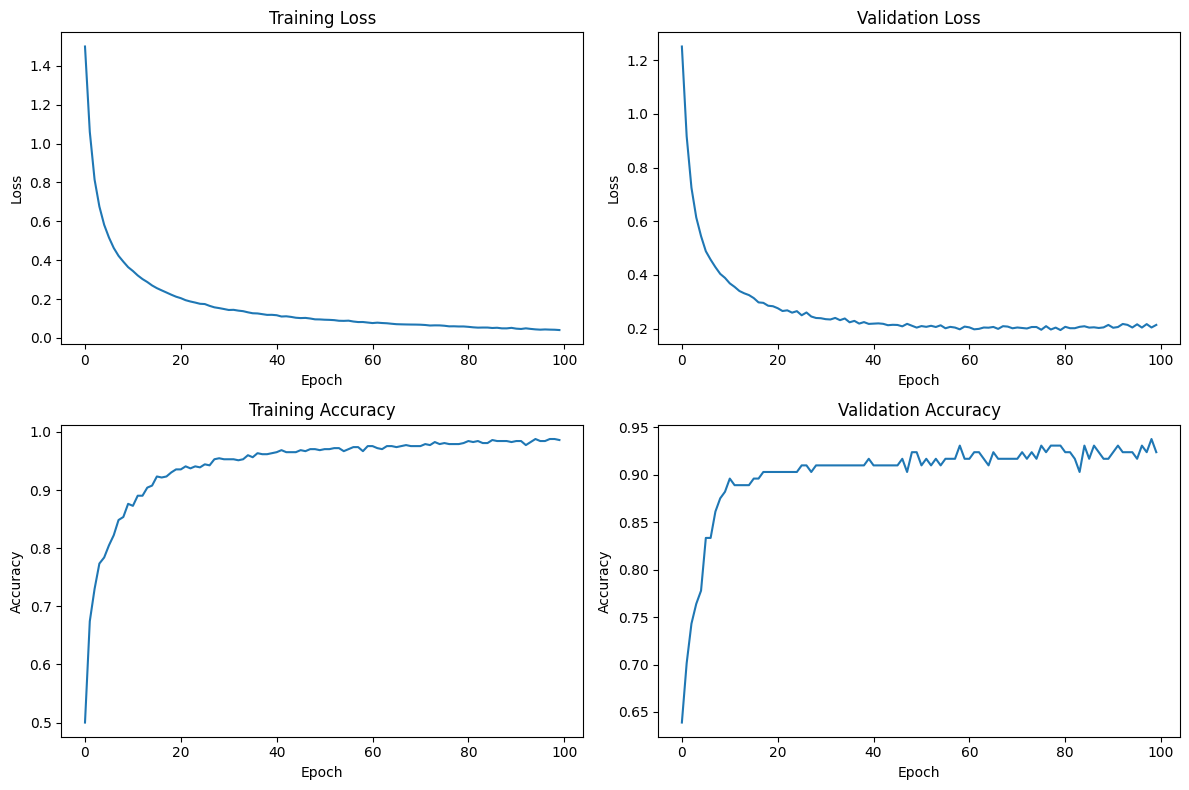

In [34]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)
# Training Loss
axes[0, 0].plot(
    history.history["loss"]
)

axes[0, 0].set_title("Training Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")


# Validation Loss
axes[0, 1].plot(
    history.history["val_loss"]
)

axes[0, 1].set_title("Validation Loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")


# Training Accuracy
axes[1, 0].plot(
    history.history["accuracy"]
)

axes[1, 0].set_title("Training Accuracy")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Accuracy")


# Validation Accuracy
axes[1, 1].plot(
    history.history["val_accuracy"]
)

axes[1, 1].set_title("Validation Accuracy")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")


fig.tight_layout()

plt.show()

In [ ]:
X_train_tensor = torch.tensor(X_train_scale, dtype = torch.float32)
X_test_tensor =  torch.tensor(X_test_scale, dtype = torch.float32)

y_train_tensor = torch.tensor(y_train,  dtype = torch.long)
y_test_tensor = torch.tensor(y_test,  dtype=torch.long)
print(X_test_tensor)
print(y_train_tensor)

trianDataset = TensorDataset(X_train_tensor, y_train_tensor)
testDataset = TensorDataset(X_test_tensor,  y_test_tensor)

train_loader = DataLoader(trianDataset, batch_size=32, shuffle=True)
test_loader = DataLoader(testDataset, batch_size = 32, shuffle= False)

class Artificial_neural_network(nn.Module):
    def __init__(self):
        super(Artificial_neural_network, self).__init__()
        self.input_layer = nn.Linear(X_train_tensor.shape[1], 32)
        self.hidden_layer1 = nn.Linear(32, 32)
        self.output_layer = nn.Linear(32, 7)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.input_layer(x)
        x = self.relu(x)
        x = self.hidden_layer1(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x

epochs = 100
learning_rate = 0.001

model = Artificial_neural_network()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
  running_loss = 0.0
  model.train();
  for batch_idx, (data, target) in enumerate(train_loader):
    optimizer.zero_grad()
    output = model(data)
    loss = criterion(output, target)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  train_loss = running_loss / len(train_loader)
  print(f"epoch = {epoch+1}/{epochs}, loss = {train_loss}")



model.eval()

total = 0
correct = 0

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb) # [0.2, 0.5, 1.3, -0.5, ..] - 7 vals
        _values, indices = torch.max(outputs, dim=1)
        print(indices )
        # print(outputs)
        correct += (indices == yb).sum().item()
        total += yb.size(0) # actual samples in each batch

print("accuracy: ", correct/total * 100)
# print(accuracy_score())

tensor([[-1.4681, -1.5104, -1.6110,  ...,  1.7157,  1.8864,  1.3899],
        [-0.3808, -0.2304,  0.0503,  ..., -2.0761, -1.8388, -1.7477],
        [-1.3722, -1.3848, -1.4493,  ..., -0.0923, -0.1138, -0.1319],
        ...,
        [-0.4487, -0.2655, -0.1040,  ...,  0.9154,  0.9146,  0.9736],
        [ 0.5883,  0.3596,  0.2474,  ...,  0.1883,  0.3185,  0.2283],
        [-1.3555, -1.2297, -1.1075,  ...,  1.3047,  1.6137,  1.4415]])
tensor([6, 5, 2, 3, 1, 3, 2, 0, 0, 5, 4, 5, 2, 1, 2, 4, 4, 4, 5, 4, 6, 6, 4, 2,
        5, 5, 5, 4, 4, 2, 4, 6, 5, 6, 2, 0, 5, 1, 4, 3, 1, 2, 6, 2, 2, 3, 2, 5,
        2, 4, 0, 2, 6, 4, 2, 1, 4, 6, 5, 5, 5, 5, 3, 4, 3, 4, 3, 6, 5, 2, 4, 1,
        1, 3, 0, 3, 3, 4, 6, 2, 1, 4, 4, 5, 4, 5, 6, 2, 3, 5, 2, 2, 4, 6, 2, 6,
        1, 6, 2, 5, 5, 1, 1, 3, 6, 1, 2, 0, 4, 2, 2, 4, 4, 3, 1, 2, 0, 4, 4, 1,
        5, 3, 5, 1, 2, 2, 5, 3, 1, 4, 4, 2, 0, 4, 1, 3, 0, 2, 4, 6, 0, 2, 3, 3,
        0, 3, 6, 5, 2, 4, 5, 3, 5, 0, 5, 4, 1, 0, 2, 2, 2, 5, 0, 2, 4, 4, 2, 4,
      